In [143]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [86]:
matplotlib.style.use('ggplot')
%matplotlib inline

In [87]:
beverage_r_df = pd.read_csv('beverage_r.csv', sep = ";", index_col = "numb.obs")

In [88]:
beverage_r_df.head()

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP
numb.obs,,,,,,,,
1,1,0,0,0,1,1,0,1
2,1,0,0,0,1,0,0,0
3,1,0,0,0,1,0,0,0
4,0,1,0,1,0,0,1,0
5,1,0,0,0,1,0,0,0


In [89]:
link = linkage(beverage_r_df, 'ward', 'euclidean')

In [90]:
link[:5]

array([[ 5., 10.,  0.,  2.],
       [ 1.,  2.,  0.,  2.],
       [ 4., 35.,  0.,  3.],
       [ 3., 22.,  0.,  2.],
       [20., 36.,  0.,  4.]])

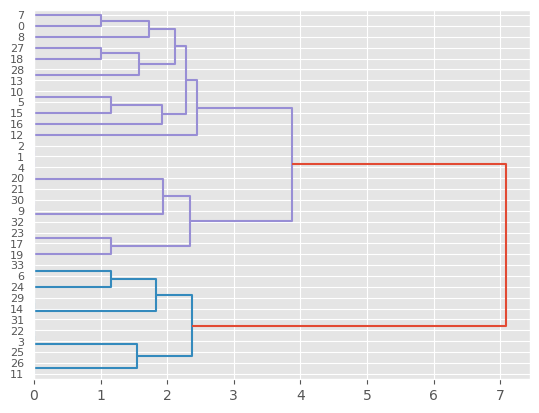

In [91]:
dn = dendrogram(link, orientation = "right")

In [92]:
beverage_r_df['cluster'] = fcluster(link, 3, criterion = 'distance')

In [93]:
beverage_r_df.groupby('cluster').mean()

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP
cluster,,,,,,,,
1,0.00,1.000000,0.545455,0.545455,0.000000,0.000000,0.909091,0.000000
2,1.00,0.272727,0.090909,0.000000,1.000000,0.000000,0.000000,0.272727
3,0.75,0.250000,0.083333,0.083333,0.416667,0.916667,0.083333,0.500000


In [94]:
beverage_r_df.groupby('cluster').size()

cluster
1    11
2    11
3    12
dtype: int64

In [95]:
dist = link[:, 2]

In [96]:
print(dist)

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         1.         1.         1.15470054
 1.15470054 1.15470054 1.54919334 1.58113883 1.73205081 1.82574186
 1.91485422 1.93649167 2.12132034 2.27636073 2.33711814 2.37920282
 2.446395   3.87646865 7.09212963]


Text(22, 2.6, '4 clusters')

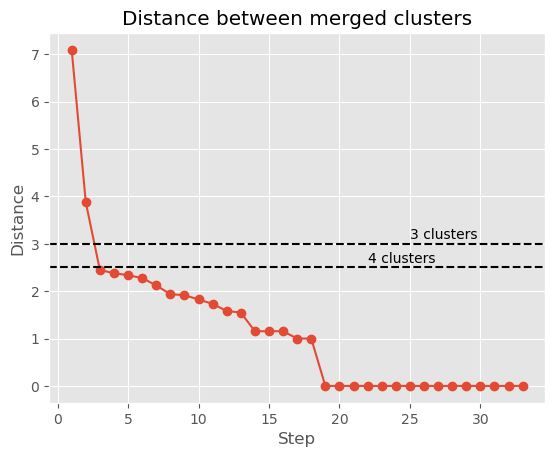

In [97]:
dist_rev = dist[::-1]
idxs = range(1, len(dist) + 1)
plt.plot(idxs, dist_rev, marker = 'o')
plt.title('Distance between merged clusters')
plt.xlabel('Step')
plt.ylabel('Distance')
plt.axhline(3, c = 'k', linestyle = 'dashed')
plt.axhline(2.52, c = 'k', linestyle = 'dashed')
plt.text(25, 3.1, '3 clusters')
plt.text(22, 2.6, '4 clusters')

In [117]:
assess_df = pd.read_csv('assess.dat', sep = "\t", index_col = "NAME")

In [118]:
del assess_df['NR']

In [119]:
assess_df = assess_df.dropna()

In [120]:
assess_df.head()

,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10
NAME,,,,,,,,,,
Volker,10,10,9,10,10,10,9,10,10,9
Sigrid,10,10,4,10,5,5,4,5,4,3
Elmar,5,4,10,5,10,4,10,5,3,10
Peter,10,10,9,10,10,10,9,10,10,9
Otto,4,3,5,4,3,10,4,10,10,5


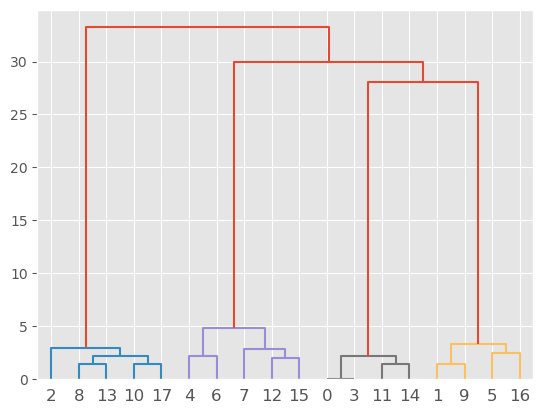

In [121]:
link = linkage(assess_df, 'ward', 'euclidean')
dn = dendrogram(link)

In [122]:
assess_df['cluster'] = fcluster(link, 5, criterion='distance')

In [123]:
assess_df.groupby('cluster').mean()

,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10
cluster,,,,,,,,,,
1,4.2,4.8,10.00,4.4,10.00,4.4,10.00,4.00,3.80,10.00
2,4.8,4.4,4.00,4.0,4.20,10.0,4.40,10.00,10.00,5.00
3,10.0,10.0,9.00,10.0,10.00,9.5,9.25,9.75,10.00,9.50
4,10.0,10.0,4.25,10.0,4.75,4.5,3.75,4.25,4.25,4.25


In [131]:
protein_consumption_in_europe_df = pd.read_csv('Protein Consumption in Europe.csv', sep = ";", decimal = ',', index_col = "Country")

In [132]:
protein_consumption_in_europe_df = protein_consumption_in_europe_df.dropna()

In [133]:
protein_consumption_in_europe_df.head()

,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr&Veg
Country,,,,,,,,,
Albania,10.1,1.4,0.5,8.9,0.2,42.3,0.6,5.5,1.7
Austria,8.9,14.0,4.3,19.9,2.1,28.0,3.6,1.3,4.3
Belgium,13.5,9.3,4.1,17.5,4.5,26.6,5.7,2.1,4.0
Bulgaria,7.8,6.0,1.6,8.3,1.2,56.7,1.1,3.7,4.2
Czechoslovakia,9.7,11.4,2.8,12.5,2.0,34.3,5.0,1.1,4.0


In [134]:
norm = preprocessing.StandardScaler()
norm.fit(protein_consumption_in_europe_df)
X = norm.transform(protein_consumption_in_europe_df)
X = pd.DataFrame(X, index = protein_consumption_in_europe_df.index, columns = protein_consumption_in_europe_df.columns)

In [135]:
X.head()

,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr&Veg
Country,,,,,,,,,
Albania,0.082941,-1.794750,-2.224584,-1.179570,-1.225033,0.934804,-2.295965,1.247968,-1.378251
Austria,-0.282974,1.686446,1.245621,0.400468,-0.655111,-0.395051,-0.422218,-0.910790,0.092789
Belgium,1.119699,0.387905,1.062979,0.055732,0.064791,-0.525246,0.889405,-0.499598,-0.076947
Bulgaria,-0.618396,-0.523837,-1.220051,-1.265754,-0.925074,2.273959,-1.983674,0.322786,0.036210
Czechoslovakia,-0.039031,0.968104,-0.124197,-0.662467,-0.685107,0.190830,0.452198,-1.013588,-0.076947


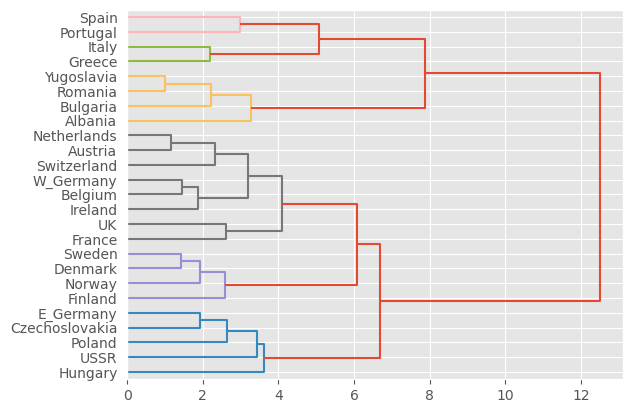

In [136]:
link = linkage(X, 'ward', 'euclidean')
dn = dendrogram(
    link,
    labels = X.index.tolist(),
    truncate_mode = 'lastp',
    color_threshold = 5,
    orientation = "right",
    leaf_rotation = 0.
)

In [138]:
protein_consumption_in_europe_df['cluster'] = fcluster(link, 5, criterion='distance')

In [139]:
protein_consumption_in_europe_df.groupby('cluster').mean()

,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr&Veg
cluster,,,,,,,,,
1,7.9200,10.0400,2.8400,13.8400,2.740,35.740,5.56,2.5400,4.260
2,9.8500,7.0500,3.1500,26.6750,8.225,22.675,4.55,1.1750,2.125
3,13.2125,10.6375,3.9875,21.1625,3.375,24.700,4.65,2.0625,4.175
4,7.1250,4.6750,1.2000,9.4500,0.750,51.125,1.95,5.0500,2.975
5,9.6000,4.0500,2.8500,15.6500,4.650,39.250,2.15,6.0500,6.600
6,6.6500,3.5500,2.1000,6.7500,10.600,28.100,5.80,5.3000,7.550


In [141]:
protein_consumption_in_europe_df['cluster'].sort_values()

Country
Poland            1
USSR              1
Czechoslovakia    1
E_Germany         1
Hungary           1
Sweden            2
Norway            2
Denmark           2
Finland           2
Netherlands       3
W_Germany         3
France            3
UK                3
Switzerland       3
Belgium           3
Austria           3
Ireland           3
Albania           4
Yugoslavia        4
Romania           4
Bulgaria          4
Greece            5
Italy             5
Portugal          6
Spain             6
Name: cluster, dtype: int32

In [165]:
beverage_r1_df = pd.read_csv('beverage_r.csv', sep = ";", index_col = "numb.obs")

In [166]:
model = KMeans(n_clusters = 2, random_state = 42)

In [167]:
model.fit(beverage_r1_df)

D:\Programmes\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [168]:
model.labels_

array([1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0], dtype=int32)

In [169]:
model.cluster_centers_

array([[ 1.11022302e-16,  9.23076923e-01,  5.38461538e-01,
         5.38461538e-01, -5.55111512e-17,  1.53846154e-01,
         7.69230769e-01,  7.69230769e-02],
       [ 9.52380952e-01,  2.38095238e-01,  4.76190476e-02,
        -8.32667268e-17,  7.61904762e-01,  4.28571429e-01,
         4.76190476e-02,  3.80952381e-01]])

In [170]:
new_items = [
    [1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0]
]
model.predict(new_items)

D:\Programmes\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([0, 1], dtype=int32)

D:\Programmes\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Programmes\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Programmes\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Programmes\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

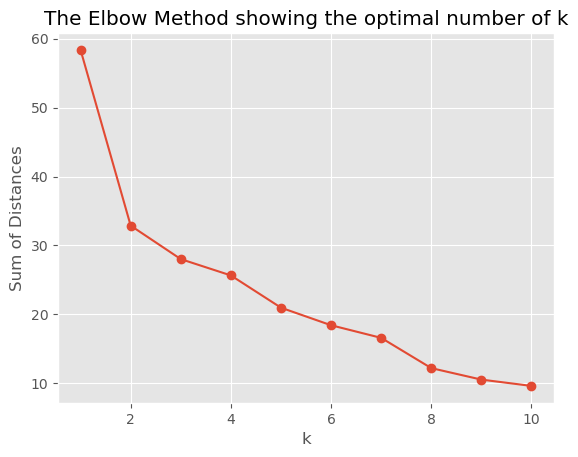

In [171]:
K = range(1, 11)
models = [KMeans(n_clusters = k, random_state = 42).fit(beverage_r1_df) for k in K]
dist = [model.inertia_ for model in models]

plt.plot(K, dist, marker = 'o')
plt.xlabel('k')
plt.ylabel('Sum of Distances')
plt.title('The Elbow Method showing the optimal number of k')
plt.show()

In [172]:
model = KMeans(n_clusters = 3, random_state = 42)
model.fit(beverage_r1_df)
beverage_r1_df['cluster'] = model.labels_
beverage_r1_df.groupby('cluster').mean()

D:\Programmes\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP
cluster,,,,,,,,
0,0.666667,0.333333,0.333333,0.333333,0.000000,1.000000,0.333333,1.000000
1,0.947368,0.210526,0.052632,0.000000,0.842105,0.368421,0.000000,0.315789
2,0.000000,1.000000,0.500000,0.500000,0.000000,0.083333,0.833333,0.000000


In [174]:
beverage_r1_df.groupby('cluster').size()

cluster
0     3
1    19
2    12
dtype: int64

In [178]:
assess1_df = pd.read_csv('assess.dat', sep = "\t", index_col = "NAME")

In [180]:
model = KMeans(n_clusters = 4, random_state = 42)
model.fit(assess1_df)
assess1_df['cluster'] = model.labels_
assess1_df.groupby('cluster').mean()

D:\Programmes\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,NR,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10
cluster,,,,,,,,,,,
0,9.80,4.8,4.4,4.00,4.0,4.20,10.0,4.40,10.00,10.00,5.00
1,11.00,4.2,4.8,10.00,4.4,10.00,4.4,10.00,4.00,3.80,10.00
2,8.75,10.0,10.0,4.25,10.0,4.75,4.5,3.75,4.25,4.25,4.25
3,8.00,10.0,10.0,9.00,10.0,10.00,9.5,9.25,9.75,10.00,9.50


In [181]:
protein_consumption_in_europe1_df = pd.read_csv('Protein Consumption in Europe.csv', sep = ";", decimal = ',', index_col = "Country")

In [182]:
protein_consumption_in_europe1_df.head()

,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr&Veg
Country,,,,,,,,,
Albania,10.1,1.4,0.5,8.9,0.2,42.3,0.6,5.5,1.7
Austria,8.9,14.0,4.3,19.9,2.1,28.0,3.6,1.3,4.3
Belgium,13.5,9.3,4.1,17.5,4.5,26.6,5.7,2.1,4.0
Bulgaria,7.8,6.0,1.6,8.3,1.2,56.7,1.1,3.7,4.2
Czechoslovakia,9.7,11.4,2.8,12.5,2.0,34.3,5.0,1.1,4.0


In [183]:
norm = preprocessing.StandardScaler()
norm.fit(protein_consumption_in_europe1_df)
X = norm.transform(protein_consumption_in_europe1_df)

D:\Programmes\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Programmes\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Programmes\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Programmes\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

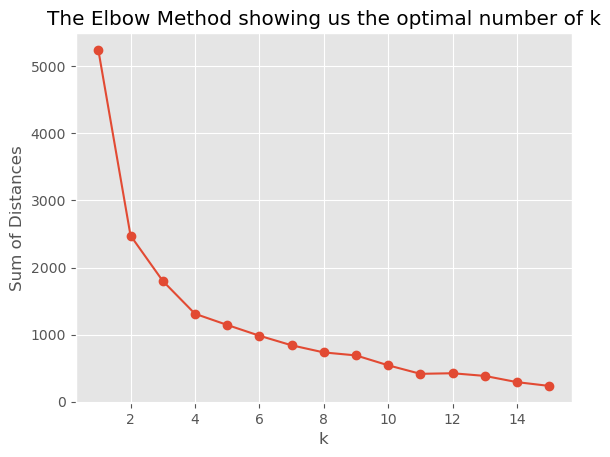

In [184]:
K = range(1, 16)
models = [KMeans(n_clusters = k).fit(protein_consumption_in_europe1_df) for k in K]
dist = [model.inertia_ for model in models]

plt.plot(K, dist, marker = 'o')
plt.xlabel('k')
plt.ylabel('Sum of Distances')
plt.title('The Elbow Method showing us the optimal number of k')
plt.show()

In [185]:
model = KMeans(n_clusters = 6)
model.fit(protein_consumption_in_europe1_df)
protein_consumption_in_europe1_df['cluster'] = model.labels_
protein_consumption_in_europe1_df.groupby('cluster').mean()

D:\Programmes\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr&Veg
cluster,,,,,,,,,
0,9.850000,7.050000,3.150000,26.675000,8.225000,22.675000,4.550000,1.175000,2.125000
1,8.400000,7.783333,2.700000,14.900000,2.933333,38.766667,4.266667,4.000000,5.150000
2,10.100000,1.400000,0.500000,8.900000,0.200000,42.300000,0.600000,5.500000,1.700000
3,12.677778,10.744444,3.955556,20.044444,3.600000,24.688889,4.855556,1.922222,4.111111
4,6.133333,5.766667,1.433333,9.633333,0.933333,54.066667,2.400000,4.900000,3.400000
5,6.650000,3.550000,2.100000,6.750000,10.600000,28.100000,5.800000,5.300000,7.550000


In [186]:
protein_consumption_in_europe1_df['cluster'].sort_values()

Country
Sweden            0
Denmark           0
Norway            0
Finland           0
Italy             1
USSR              1
Poland            1
Czechoslovakia    1
Hungary           1
Greece            1
Albania           2
Ireland           3
W_Germany         3
Netherlands       3
E_Germany         3
Belgium           3
Switzerland       3
UK                3
Austria           3
France            3
Bulgaria          4
Romania           4
Yugoslavia        4
Portugal          5
Spain             5
Name: cluster, dtype: int32